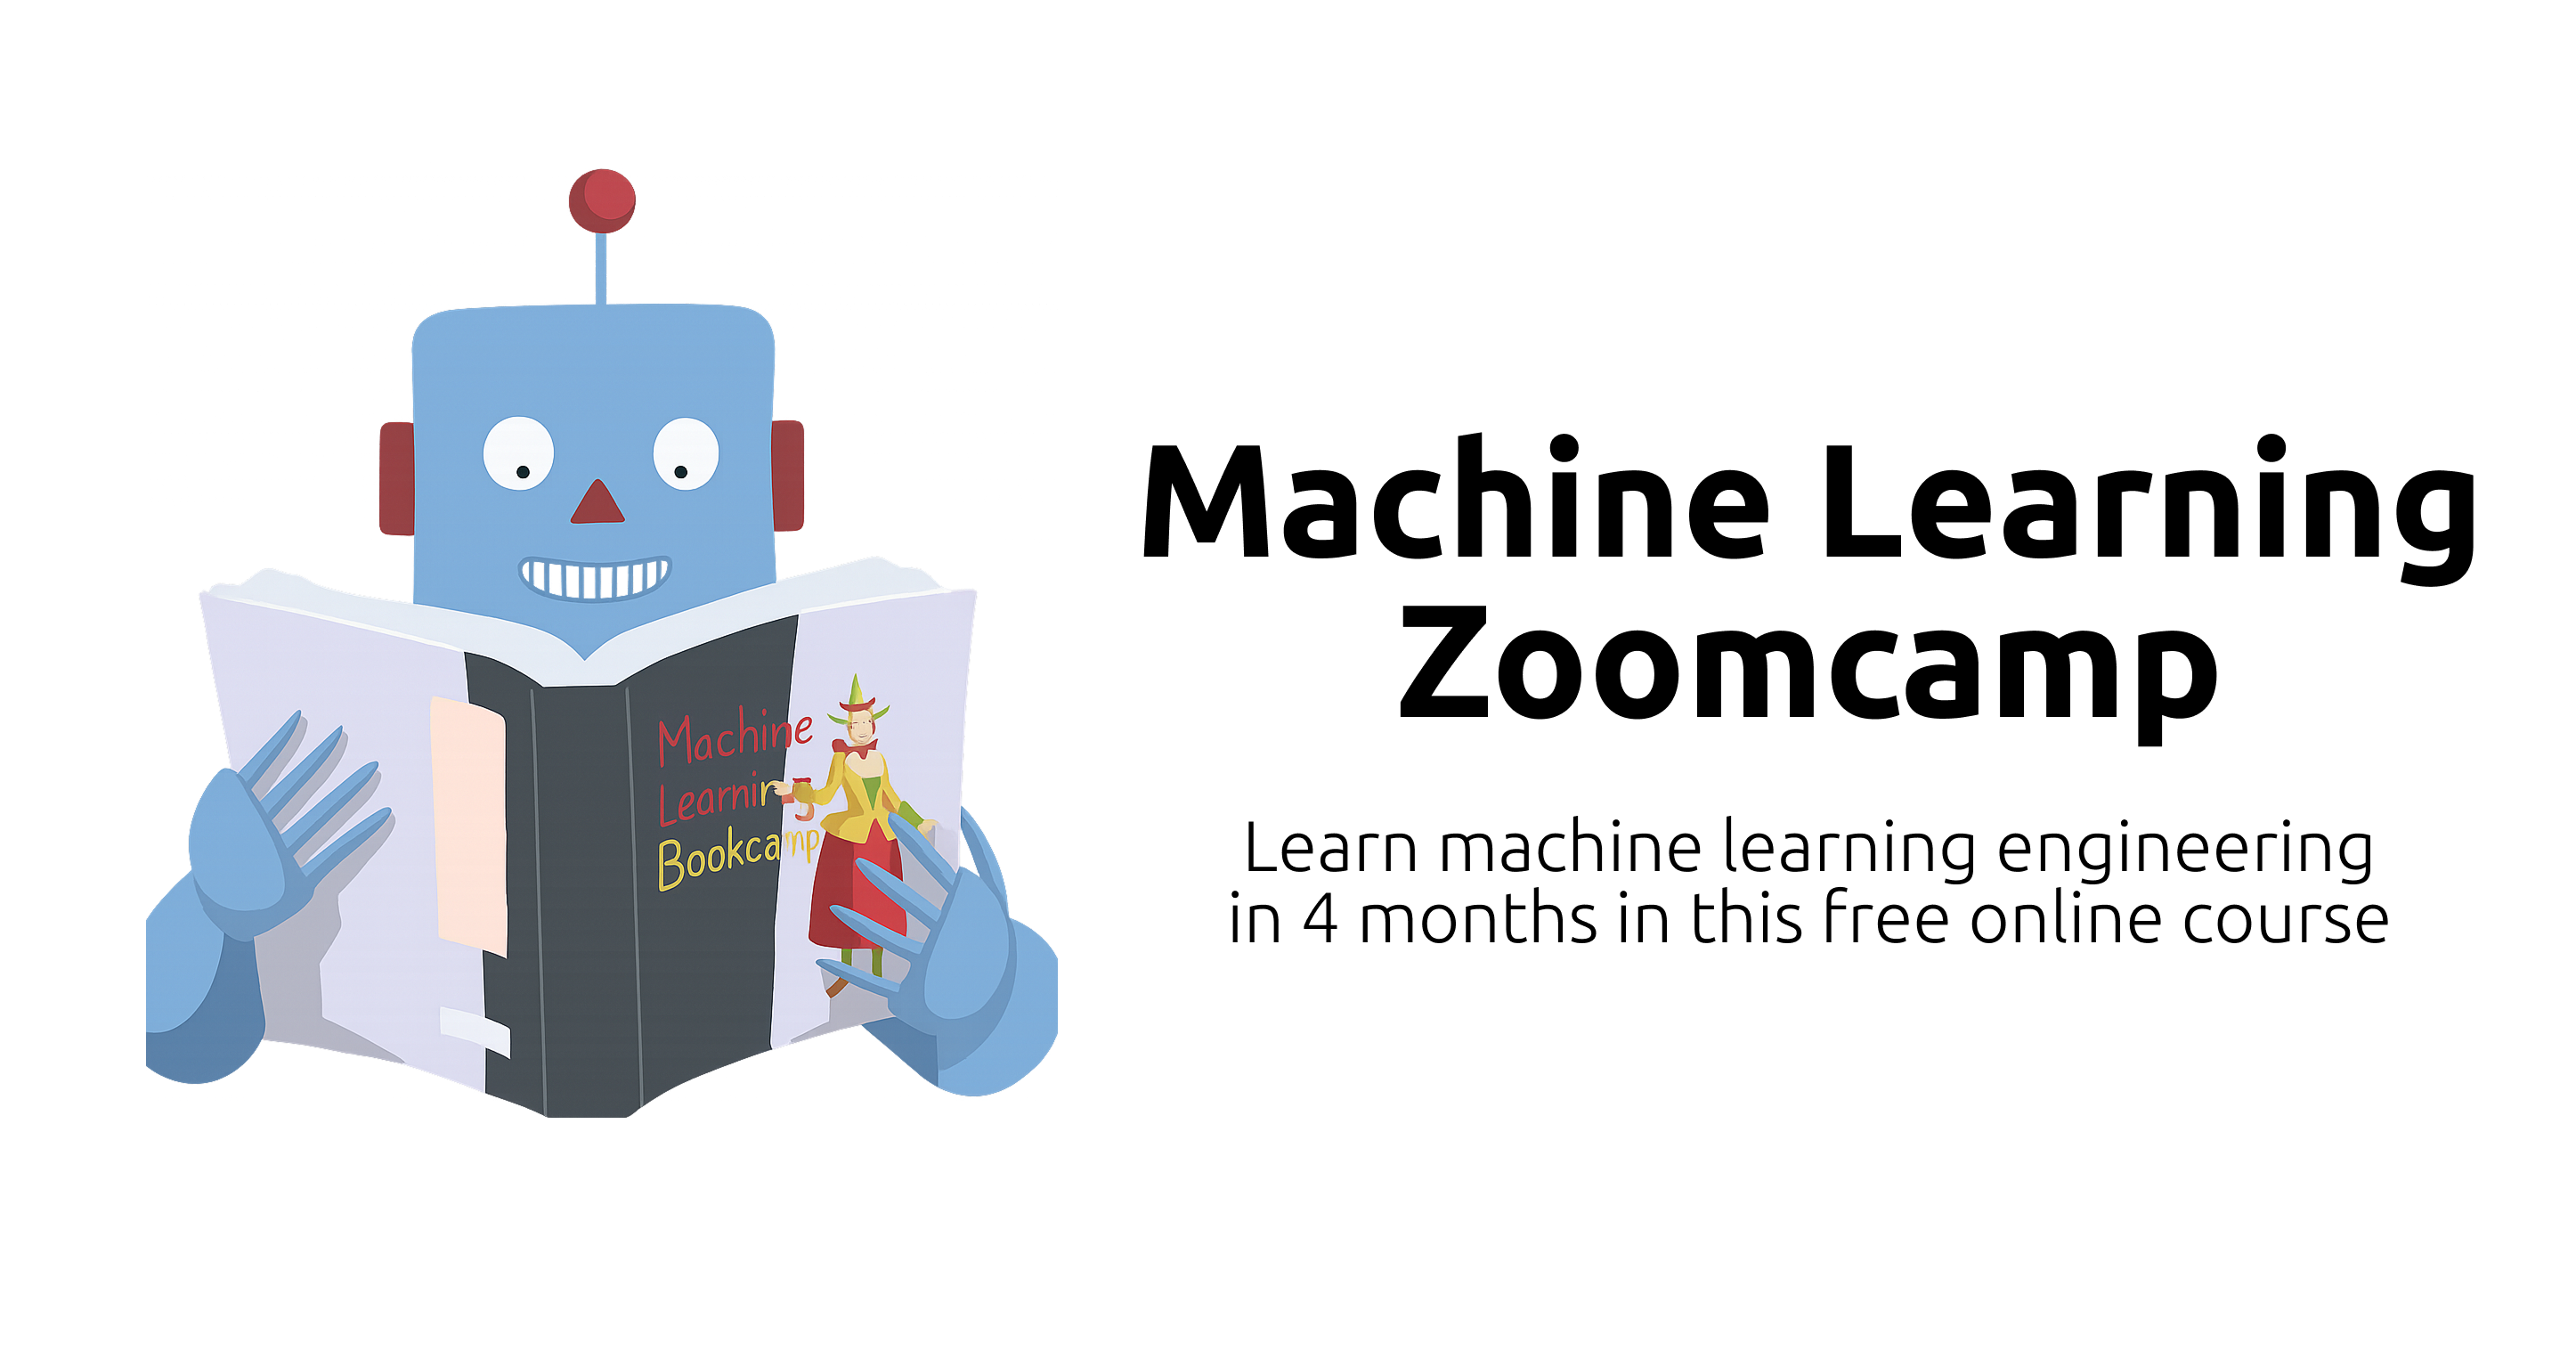

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
car_fuel = pd.read_csv('datasets/car_fuel_efficiency.csv')
car_fuel.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


Sub Dataset from categorical features

In [3]:
obj_df = car_fuel[car_fuel.dtypes[car_fuel.dtypes == 'object'].index]
obj_df.head()

,origin,fuel_type,drivetrain
0,Europe,Gasoline,All-wheel drive
1,USA,Gasoline,Front-wheel drive
2,Europe,Gasoline,Front-wheel drive
3,USA,Diesel,All-wheel drive
4,Europe,Gasoline,All-wheel drive


Transform values in all categorical features

In [16]:
obj_feat = car_fuel.dtypes[car_fuel.dtypes == 'object'].index

for feat in obj_feat:
    car_fuel[feat] = car_fuel[feat].str.lower().str.replace(' ', '_')

car_fuel[obj_feat].head()

,origin,fuel_type,drivetrain
0,europe,gasoline,all-wheel_drive
1,usa,gasoline,front-wheel_drive
2,europe,gasoline,front-wheel_drive
3,usa,diesel,all-wheel_drive
4,europe,gasoline,all-wheel_drive


```python
obj_cols = car_fuel.select_dtypes(include=['object']).columns
car_fuel[obj_cols] = car_fuel[obj_cols].apply(
    lambda x: x.str.lower().str.replace(' ', '_')
)
```

#### For this HW we should stay only 5 specific columns

In [5]:
df = car_fuel[[
    'engine_displacement', 
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]]

In [6]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


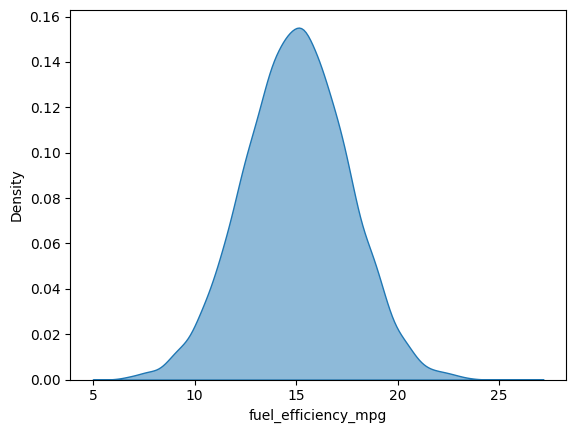

In [7]:
y = df['fuel_efficiency_mpg']

sns.kdeplot(data=df, x='fuel_efficiency_mpg', fill=True, alpha=.5);

#### Task 1

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


In [9]:
print(f'Number of missing values: {df['horsepower'].isna().sum()}')

Number of missing values: 708


The target has normal distribution

In [10]:
# Set good columns' names standard (PEP-8)
df.columns.str.lower().str.replace(' ', '_')

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='object')

#### Task 2

In [11]:
print(np.percentile(a=df['horsepower'].values, q=50))

nan


It works bad when there are NaN values in the series

In [12]:
# Target feature
print(np.percentile(a=y, q=50))
np.percentile(a=y, q=50) == y.median()

15.006036963481211


np.True_

In [13]:
print(f'Median of horsepower is {df['horsepower'].median()}')

Median of horsepower is 149.0
